# Cardiovascular Disease Classification and Risk Modeling

This notebook compares machine learning models on two cardiovascular datasets:

1. Heart Disease Dataset (`heart.csv`)
2. Cardiovascular Disease Risk Dataset (`CVD Dataset.csv`)

The workflow includes preprocessing, model comparison, confusion matrices, ROC curves, feature importance, PCA testing, and optional SHAP analysis.


## Cell 1: Import Libraries

This section loads the main packages used for data cleaning, model training, model evaluation, and plotting.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
from sklearn.inspection import permutation_importance


## Cell 2: Mount Google Drive and Set File Paths

Update these paths if the files are stored in a different folder.


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

HEART_PATH = '/content/drive/MyDrive/Colab Notebooks/ENBC 321/ML Project/heart.csv'
CVD_PATH = '/content/drive/MyDrive/Colab Notebooks/ENBC 321/ML Project/CVD Dataset.csv'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cell 3: Load Both Datasets

This cell reads both CSV files and checks the first few rows.


In [ ]:
df1 = pd.read_csv(HEART_PATH)
df2 = pd.read_csv(CVD_PATH)

print("Dataset 1: Heart Disease Dataset")
display(df1.head())
print(df1.shape)

print("\nDataset 2: CVD Risk Dataset")
display(df2.head())
print(df2.shape)


Dataset 1: Heart Disease Dataset


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


(1025, 14)

Dataset 2: CVD Risk Dataset


,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Low,N,171.0,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,High,Y,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,High,Y,183.0,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,High,Y,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,High,N,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY


(1529, 22)


## Cell 4: Define Reusable Helper Functions

These functions keep the rest of the notebook cleaner. They are used for model evaluation, repeated train/test testing, confidence intervals, and ROC plotting.


In [ ]:
def get_classification_models(random_state: int = 321) -> dict:
    """
    Returns a consistent set of classification models.
    Scaling is included for models that need it.
    """
    return {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, random_state=random_state))
        ]),
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", probability=True, random_state=random_state))
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5))
        ]),
        "Decision Tree": DecisionTreeClassifier(
            max_depth=5,
            random_state=random_state
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            random_state=random_state,
            class_weight="balanced"
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            random_state=random_state
        )
    }


def evaluate_models(models: dict, X_train, X_test, y_train, y_test, average: str = "binary") -> pd.DataFrame:
    """
    Fits each model and returns common classification metrics.
    Use average='binary' for binary classification and average='weighted' for multi-class classification.
    """
    rows = []

    for name, model in models.items():
        fitted_model = clone(model)
        fitted_model.fit(X_train, y_train)
        y_pred = fitted_model.predict(X_test)

        row = {
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average=average, zero_division=0),
            "Recall": recall_score(y_test, y_pred, average=average, zero_division=0),
            "F1 Score": f1_score(y_test, y_pred, average=average, zero_division=0)
        }

        if hasattr(fitted_model, "predict_proba"):
            y_prob = fitted_model.predict_proba(X_test)
            try:
                if average == "binary":
                    row["ROC-AUC"] = roc_auc_score(y_test, y_prob[:, 1])
                else:
                    row["ROC-AUC"] = roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted")
            except ValueError:
                row["ROC-AUC"] = np.nan
        else:
            row["ROC-AUC"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows).sort_values(by="Accuracy", ascending=False)


def repeated_accuracy_scores(models: dict, X, y, n_splits: int = 30, test_size: float = 0.2, random_state: int = 321) -> pd.DataFrame:
    """
    Repeats stratified train/test splits and stores accuracy for each model.
    This gives a better sense of model stability than one split alone.
    """
    splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        test_size=test_size,
        random_state=random_state
    )

    rows = []

    for split_id, (train_idx, test_idx) in enumerate(splitter.split(X, y), start=1):
        X_train_split = X.iloc[train_idx]
        X_test_split = X.iloc[test_idx]
        y_train_split = np.asarray(y)[train_idx]
        y_test_split = np.asarray(y)[test_idx]

        for name, model in models.items():
            fitted_model = clone(model)
            fitted_model.fit(X_train_split, y_train_split)
            y_pred_split = fitted_model.predict(X_test_split)

            rows.append({
                "Split": split_id,
                "Model": name,
                "Accuracy": accuracy_score(y_test_split, y_pred_split)
            })

    return pd.DataFrame(rows)


def summarize_repeated_scores(score_df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates mean accuracy and 95% confidence intervals from repeated split results.
    """
    summary = score_df.groupby("Model")["Accuracy"].agg(["mean", "std", "count"]).reset_index()
    summary["SEM"] = summary["std"] / np.sqrt(summary["count"])
    summary["CI95"] = 1.96 * summary["SEM"]
    summary["Lower_CI"] = summary["mean"] - summary["CI95"]
    summary["Upper_CI"] = summary["mean"] + summary["CI95"]
    return summary.sort_values(by="mean", ascending=False)


def plot_accuracy_with_ci(summary_df: pd.DataFrame, title: str):
    """
    Plots mean model accuracy with a transparent 95% confidence interval band.
    """
    plot_df = summary_df.sort_values(by="mean", ascending=True).reset_index(drop=True)
    x = np.arange(len(plot_df))

    plt.figure(figsize=(10, 6))
    plt.plot(x, plot_df["mean"], marker="o", linewidth=2)
    plt.fill_between(x, plot_df["Lower_CI"], plot_df["Upper_CI"], alpha=0.20)

    plt.xticks(x, plot_df["Model"], rotation=35, ha="right")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.ylim(0, 1)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## Cell 5: Prepare Dataset 1 Features and Target

Dataset 1 uses `target` as the heart disease label. The remaining clinical variables are used as model features.


In [ ]:
print(df1.info())
print("\nTarget counts:")
print(df1["target"].value_counts())

feature_cols_1 = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal"
]

X1 = df1[feature_cols_1].copy()
y1 = df1["target"].copy()

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=321,
    stratify=y1
)

print("Training set:", X1_train.shape)
print("Test set:", X1_test.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Target counts:
target
1    526
0    499
Name: count, dtype: int64
Training set: (820, 13)
Test set: (205, 13)


## Cell 6: Dataset 1 Correlation Heatmap

This heatmap gives an initial view of relationships between numeric variables before model training.


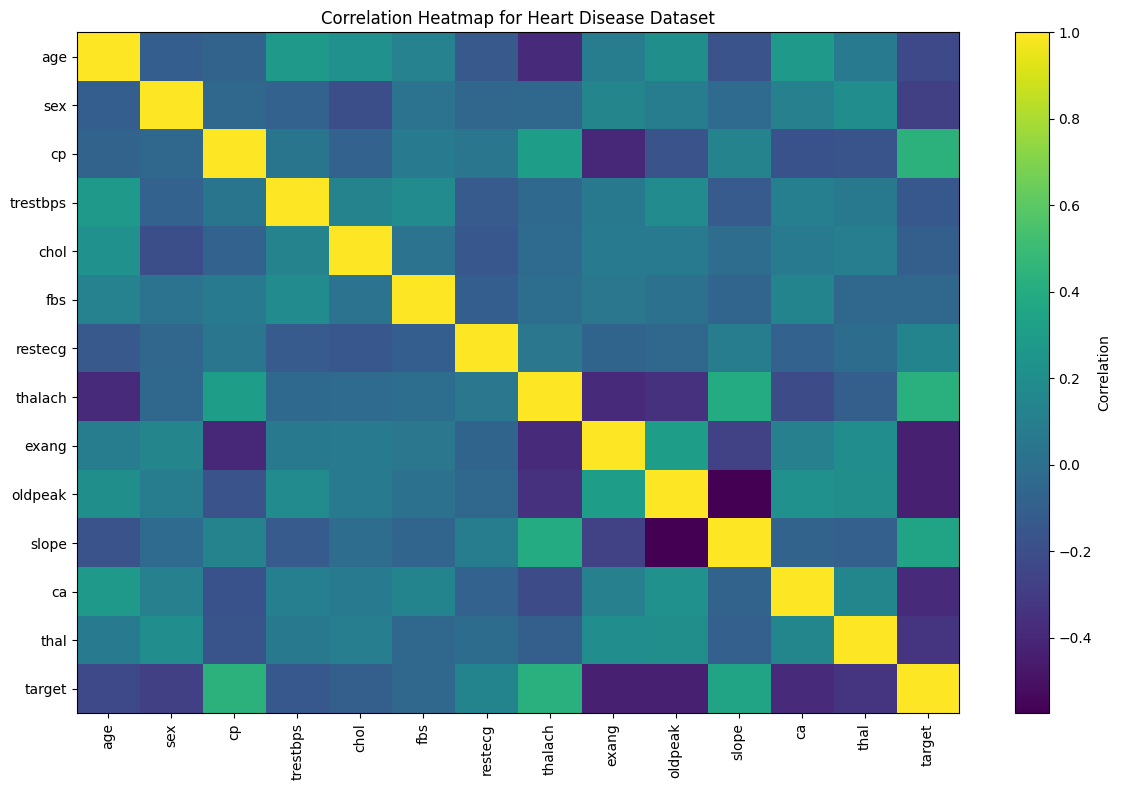

In [ ]:
plt.figure(figsize=(12, 8))
corr = df1.corr(numeric_only=True)
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Heatmap for Heart Disease Dataset")
plt.tight_layout()
plt.show()


## Cell 7: Train and Compare Models on Dataset 1

Several classification models are trained on the same train/test split so their performance can be compared directly.


In [ ]:
models1 = get_classification_models(random_state=321)

results1_df = evaluate_models(
    models=models1,
    X_train=X1_train,
    X_test=X1_test,
    y_train=y1_train,
    y_test=y1_test,
    average="binary"
)

results1_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,Random Forest,0.946341,0.935185,0.961905,0.948357,0.989048
5,Gradient Boosting,0.941463,0.926606,0.961905,0.943925,0.992667
3,Decision Tree,0.887805,0.886792,0.895238,0.890995,0.967857
1,SVM,0.873171,0.883495,0.866667,0.875000,0.959143
0,Logistic Regression,0.824390,0.794872,0.885714,0.837838,0.883333
2,KNN,0.785366,0.790476,0.790476,0.790476,0.933619


## Cell 8: Dataset 1 Confusion Matrices and Classification Reports

Confusion matrices show how each model separates patients with and without heart disease.


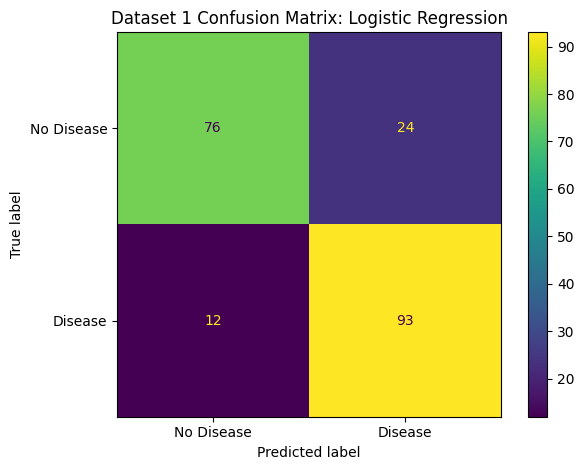


Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.86      0.76      0.81       100
     Disease       0.79      0.89      0.84       105

    accuracy                           0.82       205
   macro avg       0.83      0.82      0.82       205
weighted avg       0.83      0.82      0.82       205



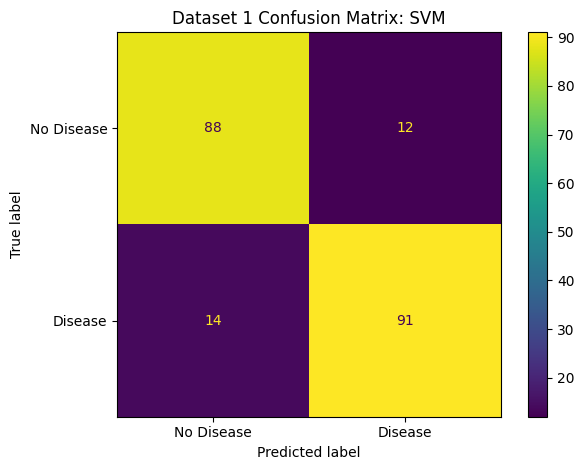


SVM
              precision    recall  f1-score   support

  No Disease       0.86      0.88      0.87       100
     Disease       0.88      0.87      0.88       105

    accuracy                           0.87       205
   macro avg       0.87      0.87      0.87       205
weighted avg       0.87      0.87      0.87       205



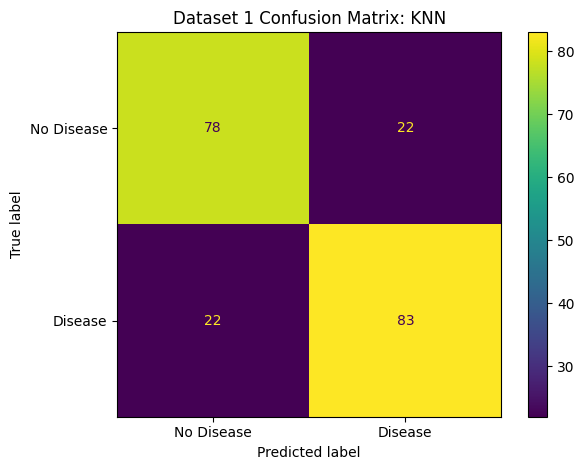


KNN
              precision    recall  f1-score   support

  No Disease       0.78      0.78      0.78       100
     Disease       0.79      0.79      0.79       105

    accuracy                           0.79       205
   macro avg       0.79      0.79      0.79       205
weighted avg       0.79      0.79      0.79       205



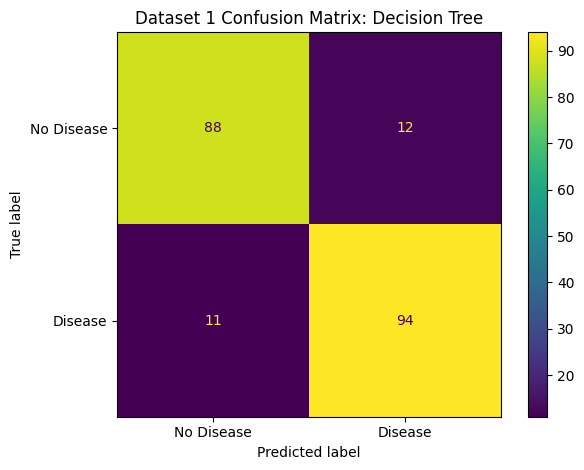


Decision Tree
              precision    recall  f1-score   support

  No Disease       0.89      0.88      0.88       100
     Disease       0.89      0.90      0.89       105

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205



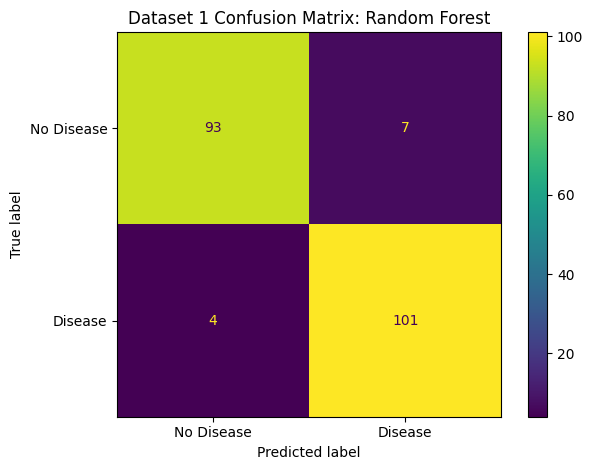


Random Forest
              precision    recall  f1-score   support

  No Disease       0.96      0.93      0.94       100
     Disease       0.94      0.96      0.95       105

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205



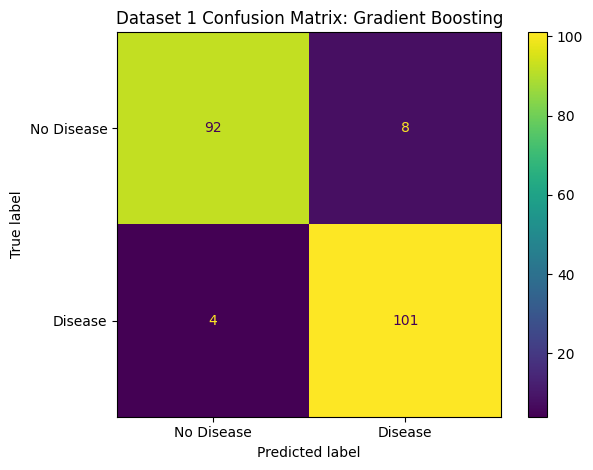


Gradient Boosting
              precision    recall  f1-score   support

  No Disease       0.96      0.92      0.94       100
     Disease       0.93      0.96      0.94       105

    accuracy                           0.94       205
   macro avg       0.94      0.94      0.94       205
weighted avg       0.94      0.94      0.94       205



In [ ]:
fitted_models1 = {}

for name, model in models1.items():
    fitted_model = clone(model)
    fitted_model.fit(X1_train, y1_train)
    fitted_models1[name] = fitted_model

    y_pred = fitted_model.predict(X1_test)
    cm = confusion_matrix(y1_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Disease", "Disease"]
    )
    disp.plot()
    plt.title(f"Dataset 1 Confusion Matrix: {name}")
    plt.tight_layout()
    plt.show()

    print(f"\n{name}")
    print(classification_report(y1_test, y_pred, target_names=["No Disease", "Disease"]))

## Cell 9: Dataset 1 Model Accuracy with 95% Confidence Interval Band

This section repeats the train/test split multiple times. The plot shows average accuracy for each model with a transparent 95% confidence interval band.


,Model,mean,std,count,SEM,CI95,Lower_CI,Upper_CI
1,Gradient Boosting,0.968618,0.015829,30,0.002890,0.005664,0.962953,0.974282
4,Random Forest,0.961951,0.015606,30,0.002849,0.005584,0.956367,0.967536
5,SVM,0.922276,0.021318,30,0.003892,0.007629,0.914648,0.929905
0,Decision Tree,0.894309,0.019187,30,0.003503,0.006866,0.887443,0.901175
2,KNN,0.841301,0.030951,30,0.005651,0.011076,0.830225,0.852376
3,Logistic Regression,0.840000,0.021980,30,0.004013,0.007866,0.832134,0.847866


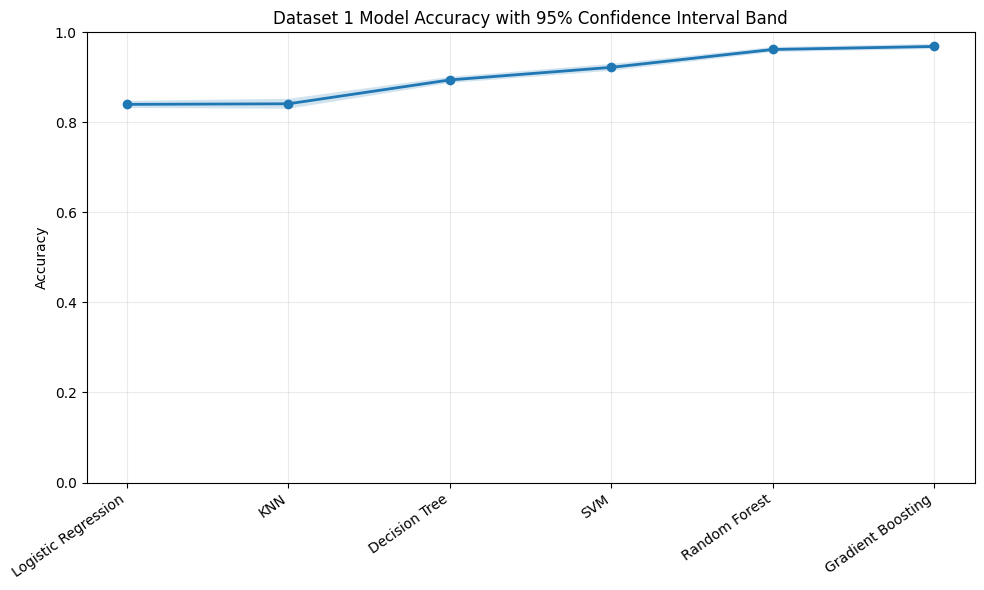

In [ ]:
scores1_df = repeated_accuracy_scores(
    models=models1,
    X=X1,
    y=y1,
    n_splits=30,
    test_size=0.2,
    random_state=321
)

summary1_ci = summarize_repeated_scores(scores1_df)
display(summary1_ci)

plot_accuracy_with_ci(
    summary_df=summary1_ci,
    title="Dataset 1 Model Accuracy with 95% Confidence Interval Band"
)


## Cell 10: Dataset 1 ROC Curves with Bootstrap Confidence Bands

This plot compares binary ROC curves for all models. The transparent bands show variation from bootstrap resampling.


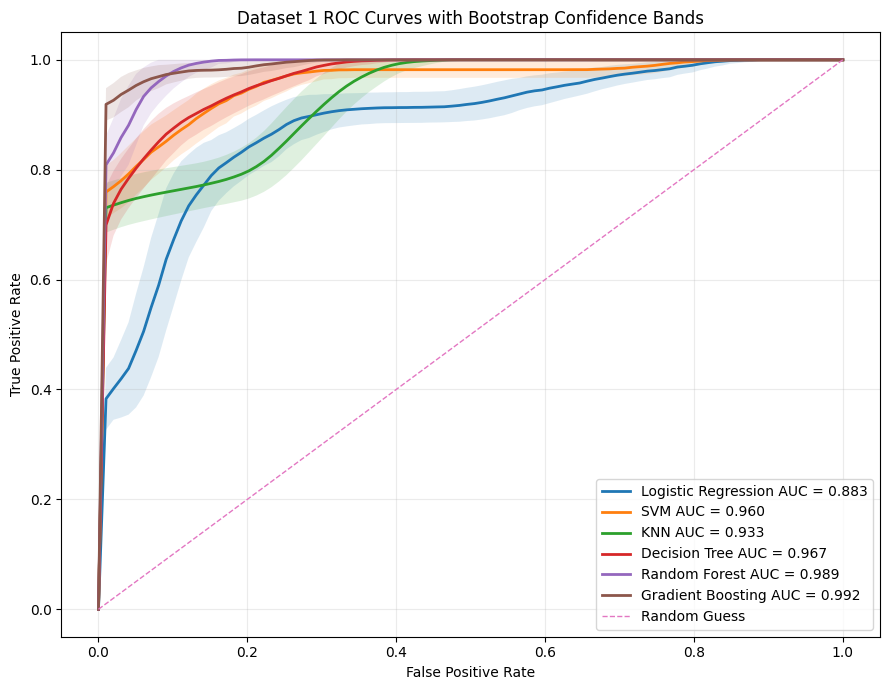

In [ ]:
def plot_binary_roc_with_bands(models: dict, X_train, X_test, y_train, y_test, title: str, n_bootstraps: int = 300):
    plt.figure(figsize=(9, 7))
    rng = np.random.RandomState(321)
    mean_fpr = np.linspace(0, 1, 100)

    for name, model in models.items():
        fitted_model = clone(model)
        fitted_model.fit(X_train, y_train)

        if hasattr(fitted_model, "predict_proba"):
            y_score = fitted_model.predict_proba(X_test)[:, 1]
        elif hasattr(fitted_model, "decision_function"):
            y_score = fitted_model.decision_function(X_test)
        else:
            continue

        y_test_array = np.asarray(y_test)
        y_score_array = np.asarray(y_score)
        tprs = []
        aucs = []

        for _ in range(n_bootstraps):
            indices = rng.randint(0, len(y_score_array), len(y_score_array))

            if len(np.unique(y_test_array[indices])) < 2:
                continue

            fpr_boot, tpr_boot, _ = roc_curve(y_test_array[indices], y_score_array[indices])
            interp_tpr = np.interp(mean_fpr, fpr_boot, tpr_boot)
            interp_tpr[0] = 0.0

            tprs.append(interp_tpr)
            aucs.append(auc(fpr_boot, tpr_boot))

        tprs = np.array(tprs)
        mean_tpr = np.mean(tprs, axis=0)
        std_tpr = np.std(tprs, axis=0)

        tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
        tpr_lower = np.maximum(mean_tpr - std_tpr, 0)

        plt.plot(mean_fpr, mean_tpr, linewidth=2, label=f"{name} AUC = {np.mean(aucs):.3f}")
        plt.fill_between(mean_fpr, tpr_lower, tpr_upper, alpha=0.15)

    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_binary_roc_with_bands(
    models=models1,
    X_train=X1_train,
    X_test=X1_test,
    y_train=y1_train,
    y_test=y1_test,
    title="Dataset 1 ROC Curves with Bootstrap Confidence Bands"
)


## Cell 11: Dataset 1 Random Forest Feature Importance

This section identifies which variables were most useful to the Random Forest model.


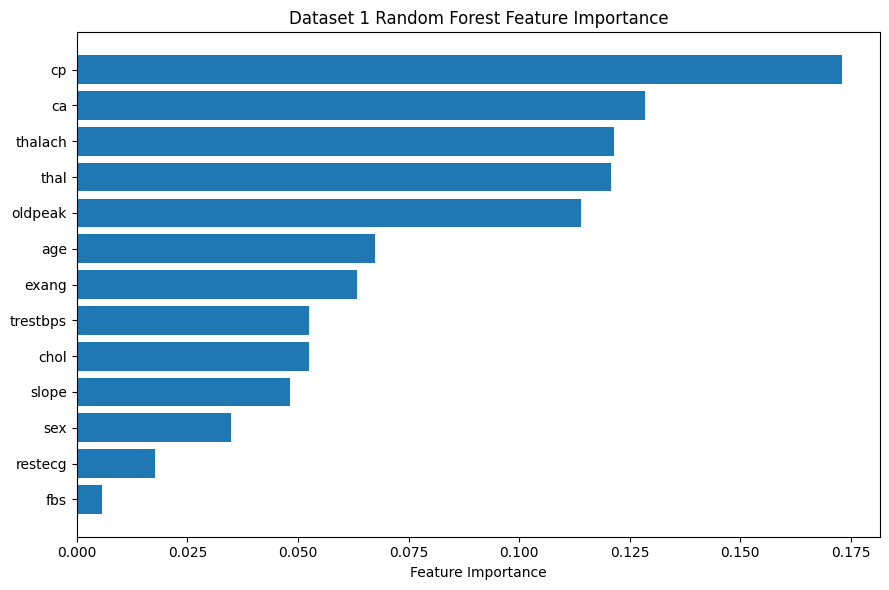

,Feature,Importance
2,cp,0.172928
11,ca,0.128387
7,thalach,0.121474
12,thal,0.120762
9,oldpeak,0.113988
0,age,0.067506
8,exang,0.063362
3,trestbps,0.052552
4,chol,0.052477
10,slope,0.048312


In [ ]:
rf1 = clone(models1["Random Forest"])
rf1.fit(X1_train, y1_train)

rf1_importance = pd.DataFrame({
    "Feature": X1.columns,
    "Importance": rf1.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(rf1_importance["Feature"], rf1_importance["Importance"])
plt.xlabel("Feature Importance")
plt.title("Dataset 1 Random Forest Feature Importance")
plt.tight_layout()
plt.show()

rf1_importance.sort_values(by="Importance", ascending=False)


## Cell 12: Dataset 1 Permutation Importance

Permutation importance tests how much model performance drops when each feature is randomly shuffled.


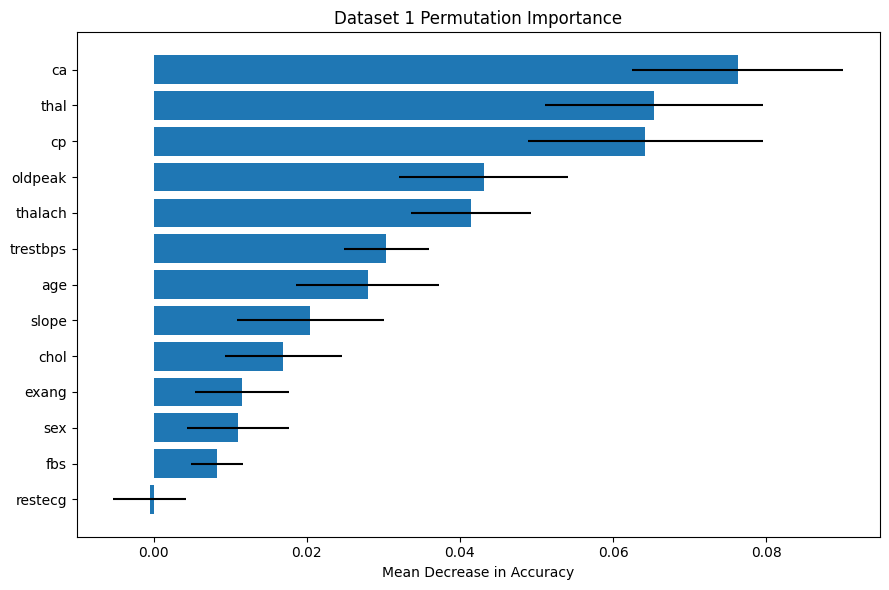

,Feature,Importance,Std
11,ca,0.076260,0.013825
12,thal,0.065366,0.014227
2,cp,0.064228,0.015379
9,oldpeak,0.043089,0.010986
7,thalach,0.041463,0.007840
3,trestbps,0.030407,0.005588
0,age,0.027967,0.009335
10,slope,0.020488,0.009542
4,chol,0.016911,0.007634
8,exang,0.011545,0.006104


In [ ]:
perm1 = permutation_importance(
    rf1,
    X1_test,
    y1_test,
    n_repeats=30,
    random_state=321
)

perm1_df = pd.DataFrame({
    "Feature": X1.columns,
    "Importance": perm1.importances_mean,
    "Std": perm1.importances_std
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(perm1_df["Feature"], perm1_df["Importance"], xerr=perm1_df["Std"])
plt.xlabel("Mean Decrease in Accuracy")
plt.title("Dataset 1 Permutation Importance")
plt.tight_layout()
plt.show()

perm1_df.sort_values(by="Importance", ascending=False)


## Cell 13: Dataset 1 PCA Model Comparison

PCA is tested as an optional dimensionality reduction step. This helps show whether compressed features perform similarly to the original features.


In [ ]:
pca_models1 = {
    "Logistic Regression + PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", LogisticRegression(max_iter=2000, random_state=321))
    ]),
    "SVM + PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", SVC(kernel="rbf", probability=True, random_state=321))
    ]),
    "KNN + PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ])
}

pca_results1_df = evaluate_models(
    models=pca_models1,
    X_train=X1_train,
    X_test=X1_test,
    y_train=y1_train,
    y_test=y1_test,
    average="binary"
)

pca_results1_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,SVM + PCA,0.858537,0.865385,0.857143,0.861244,0.957333
0,Logistic Regression + PCA,0.824390,0.794872,0.885714,0.837838,0.886190
2,KNN + PCA,0.790244,0.798077,0.790476,0.794258,0.933048


## Cell 14: SHAP Analysis for Dataset 1

SHAP can be used to visualize how features contribute to predictions. This cell is optional because SHAP may need to be installed first.


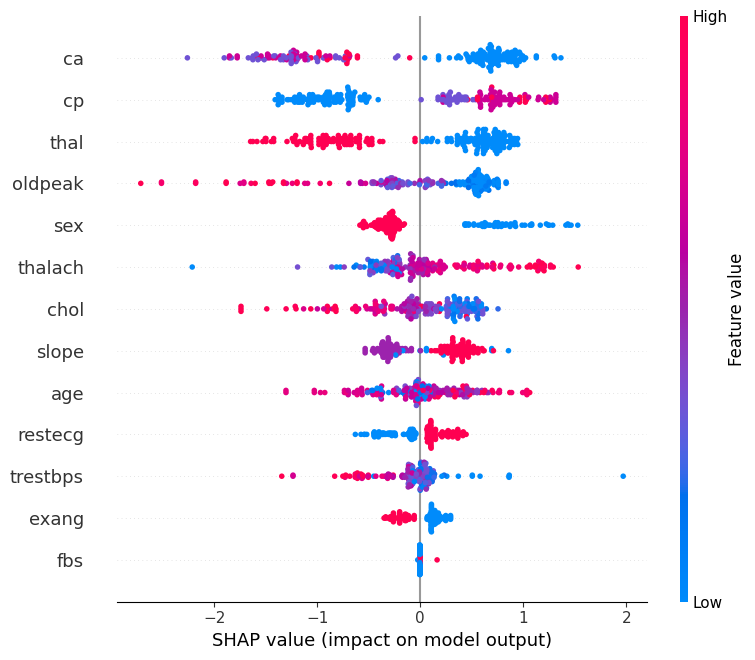

In [ ]:
try:
    import shap
except ImportError:
    !pip install shap
    import shap

best_model1 = GradientBoostingClassifier(random_state=321)
best_model1.fit(X1_train, y1_train)

explainer1 = shap.Explainer(best_model1, X1_train)
shap_values1 = explainer1(X1_test)

shap.summary_plot(shap_values1, X1_test)


## Cell 15: Prepare Dataset 2 Features and Target

Dataset 2 uses `CVD Risk Level` as the target. Columns that directly duplicate or leak the target are removed before training.


In [ ]:
print(df2.info())
print("\nTarget counts:")
print(df2["CVD Risk Level"].value_counts())

leakage_cols_2 = [
    "Blood Pressure (mmHg)",
    "Blood Pressure Category",
    "CVD Risk Score"
]

existing_leakage_cols_2 = [col for col in leakage_cols_2 if col in df2.columns]

df2_model = df2.drop(columns=existing_leakage_cols_2).copy()
df2_model = df2_model.dropna(subset=["CVD Risk Level"])

X2_raw = df2_model.drop(columns=["CVD Risk Level"])
y2_raw = df2_model["CVD Risk Level"]

X2 = pd.get_dummies(X2_raw, drop_first=True)
X2 = X2.fillna(X2.median(numeric_only=True))

label_encoder2 = LabelEncoder()
y2 = label_encoder2.fit_transform(y2_raw)

print("Target classes:", list(label_encoder2.classes_))
print("Encoded target counts:")
print(pd.Series(y2).value_counts().sort_index())

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=321,
    stratify=y2
)

print("Training set:", X2_train.shape)
print("Test set:", X2_test.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   object 
 1   Age                           1451 non-null   float64
 2   Weight (kg)                   1448 non-null   float64
 3   Height (m)                    1462 non-null   float64
 4   BMI                           1465 non-null   float64
 5   Abdominal Circumference (cm)  1462 non-null   float64
 6   Blood Pressure (mmHg)         1529 non-null   object 
 7   Total Cholesterol (mg/dL)     1456 non-null   float64
 8   HDL (mg/dL)                   1449 non-null   float64
 9   Fasting Blood Sugar (mg/dL)   1462 non-null   float64
 10  Smoking Status                1529 non-null   object 
 11  Diabetes Status               1529 non-null   object 
 12  Physical Activity Level       1529 non-null   object 
 13  Fam

## Cell 16: Train and Compare Models on Dataset 2

The same model families are tested on the CVD risk dataset. Weighted metrics are used because this is a multi-class classification task.


In [ ]:
models2 = get_classification_models(random_state=321)

results2_df = evaluate_models(
    models=models2,
    X_train=X2_train,
    X_test=X2_test,
    y_train=y2_train,
    y_test=y2_test,
    average="weighted"
)

results2_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.656863,0.612584,0.656863,0.611966,0.772427
5,Gradient Boosting,0.650327,0.596875,0.650327,0.618267,0.790931
4,Random Forest,0.637255,0.624339,0.637255,0.629436,0.808183
1,SVM,0.620915,0.604432,0.620915,0.582502,0.791229
3,Decision Tree,0.555556,0.550943,0.555556,0.541312,0.677614
2,KNN,0.555556,0.499510,0.555556,0.519466,0.698057


## Cell 17: Dataset 2 Confusion Matrices and Classification Reports

These matrices show which CVD risk levels are predicted correctly and which classes are most often confused.


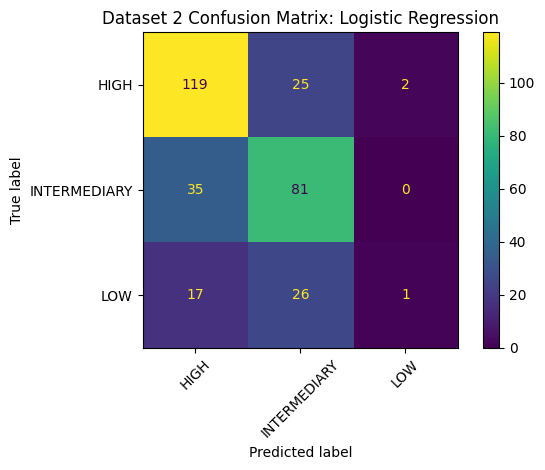


Logistic Regression
              precision    recall  f1-score   support

        HIGH       0.70      0.82      0.75       146
INTERMEDIARY       0.61      0.70      0.65       116
         LOW       0.33      0.02      0.04        44

    accuracy                           0.66       306
   macro avg       0.55      0.51      0.48       306
weighted avg       0.61      0.66      0.61       306



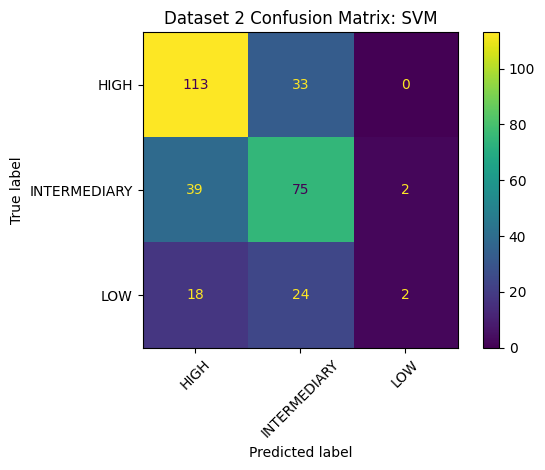


SVM
              precision    recall  f1-score   support

        HIGH       0.66      0.77      0.72       146
INTERMEDIARY       0.57      0.65      0.60       116
         LOW       0.50      0.05      0.08        44

    accuracy                           0.62       306
   macro avg       0.58      0.49      0.47       306
weighted avg       0.60      0.62      0.58       306



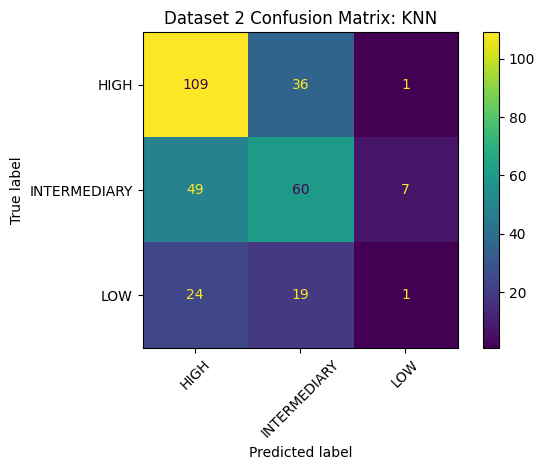


KNN
              precision    recall  f1-score   support

        HIGH       0.60      0.75      0.66       146
INTERMEDIARY       0.52      0.52      0.52       116
         LOW       0.11      0.02      0.04        44

    accuracy                           0.56       306
   macro avg       0.41      0.43      0.41       306
weighted avg       0.50      0.56      0.52       306



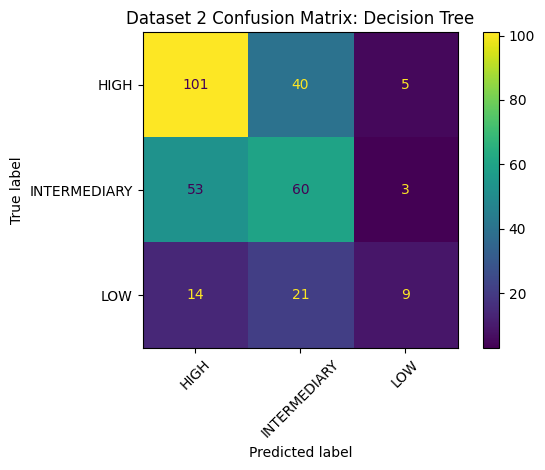


Decision Tree
              precision    recall  f1-score   support

        HIGH       0.60      0.69      0.64       146
INTERMEDIARY       0.50      0.52      0.51       116
         LOW       0.53      0.20      0.30        44

    accuracy                           0.56       306
   macro avg       0.54      0.47      0.48       306
weighted avg       0.55      0.56      0.54       306



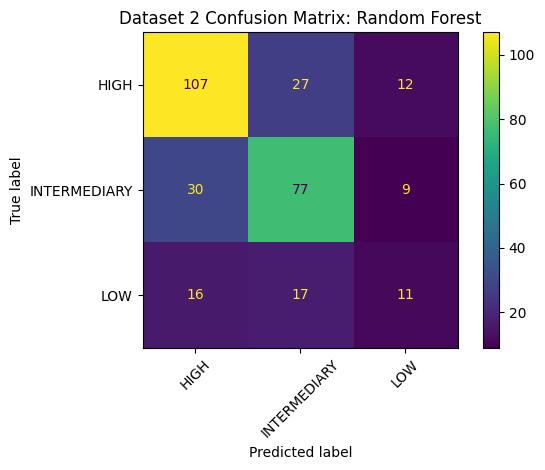


Random Forest
              precision    recall  f1-score   support

        HIGH       0.70      0.73      0.72       146
INTERMEDIARY       0.64      0.66      0.65       116
         LOW       0.34      0.25      0.29        44

    accuracy                           0.64       306
   macro avg       0.56      0.55      0.55       306
weighted avg       0.62      0.64      0.63       306



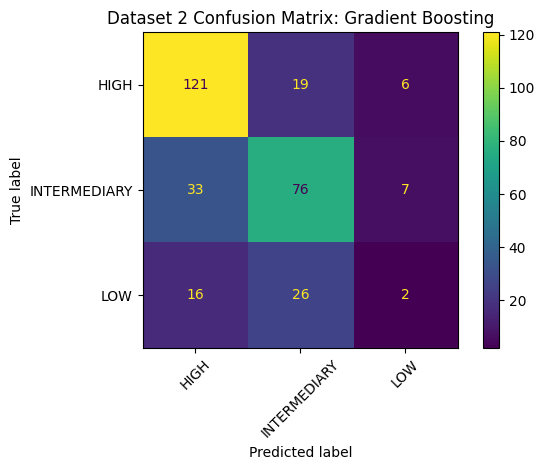


Gradient Boosting
              precision    recall  f1-score   support

        HIGH       0.71      0.83      0.77       146
INTERMEDIARY       0.63      0.66      0.64       116
         LOW       0.13      0.05      0.07        44

    accuracy                           0.65       306
   macro avg       0.49      0.51      0.49       306
weighted avg       0.60      0.65      0.62       306



In [ ]:
fitted_models2 = {}

for name, model in models2.items():
    fitted_model = clone(model)
    fitted_model.fit(X2_train, y2_train)
    fitted_models2[name] = fitted_model

    y2_pred = fitted_model.predict(X2_test)
    cm = confusion_matrix(y2_test, y2_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder2.classes_
    )
    disp.plot(xticks_rotation=45)
    plt.title(f"Dataset 2 Confusion Matrix: {name}")
    plt.tight_layout()
    plt.show()

    print(f"\n{name}")
    print(classification_report(y2_test, y2_pred, target_names=label_encoder2.classes_))


## Cell 18: Dataset 2 Model Accuracy with 95% Confidence Interval Band

This plot repeats the train/test split and compares mean model accuracy with a transparent 95% confidence interval band.


,Model,mean,std,count,SEM,CI95,Lower_CI,Upper_CI
1,Gradient Boosting,0.663508,0.024447,30,0.004463,0.008748,0.654759,0.672256
3,Logistic Regression,0.656100,0.018972,30,0.003464,0.006789,0.649311,0.662889
5,SVM,0.648039,0.027572,30,0.005034,0.009866,0.638173,0.657906
4,Random Forest,0.615142,0.032108,30,0.005862,0.011490,0.603652,0.626631
2,KNN,0.597821,0.024090,30,0.004398,0.008621,0.589201,0.606442
0,Decision Tree,0.562200,0.019934,30,0.003639,0.007133,0.555067,0.569334


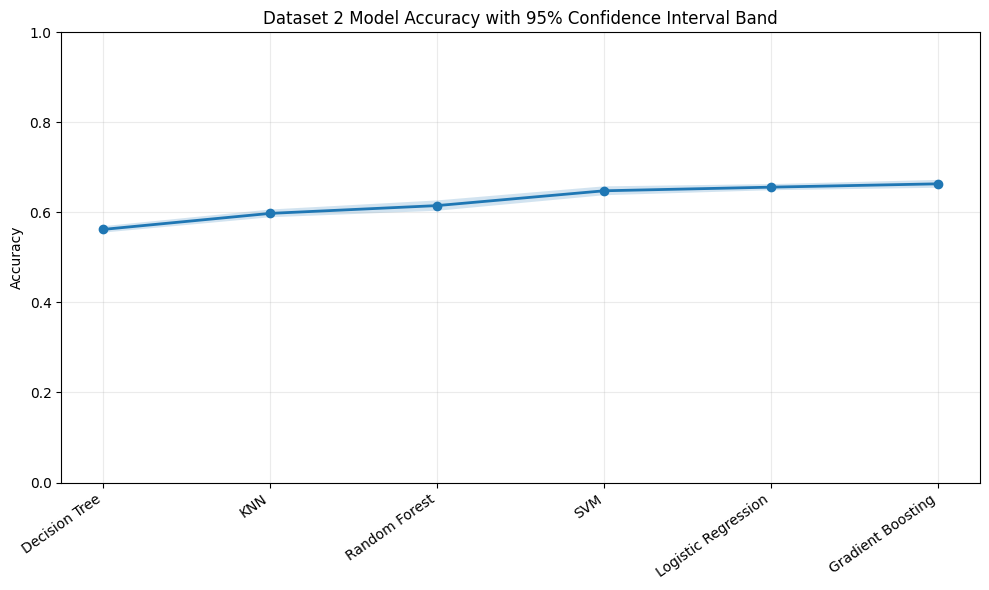

In [ ]:
scores2_df = repeated_accuracy_scores(
    models=models2,
    X=X2,
    y=y2,
    n_splits=30,
    test_size=0.2,
    random_state=321
)

summary2_ci = summarize_repeated_scores(scores2_df)
display(summary2_ci)

plot_accuracy_with_ci(
    summary_df=summary2_ci,
    title="Dataset 2 Model Accuracy with 95% Confidence Interval Band"
)


## Cell 19: Dataset 2 Multi-Class ROC Curves with Bootstrap Confidence Bands

For the multi-class target, this section calculates a macro-average ROC curve for each model.


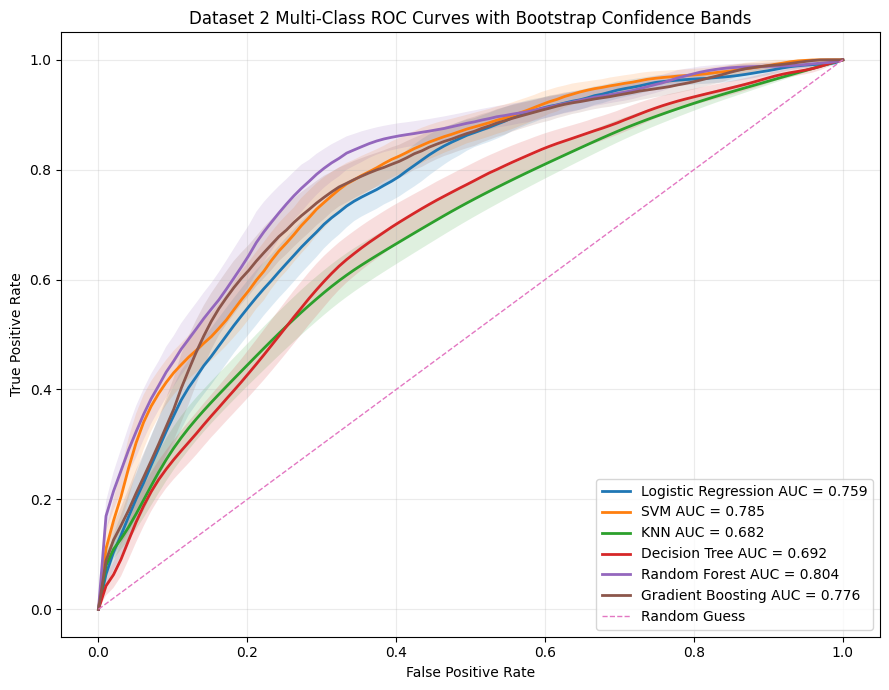

In [ ]:
def plot_multiclass_roc_with_bands(models: dict, X_train, X_test, y_train, y_test, title: str, n_bootstraps: int = 300):
    plt.figure(figsize=(9, 7))
    rng = np.random.RandomState(321)
    mean_fpr = np.linspace(0, 1, 100)

    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)

    for name, model in models.items():
        fitted_model = clone(model)
        fitted_model.fit(X_train, y_train)

        if not hasattr(fitted_model, "predict_proba"):
            continue

        y_score = fitted_model.predict_proba(X_test)
        y_test_array = np.asarray(y_test)
        y_score_array = np.asarray(y_score)

        tprs = []
        aucs = []

        for _ in range(n_bootstraps):
            indices = rng.randint(0, len(y_test_array), len(y_test_array))

            if len(np.unique(y_test_array[indices])) < len(classes):
                continue

            y_boot = y_test_array[indices]
            score_boot = y_score_array[indices]
            y_boot_bin = label_binarize(y_boot, classes=classes)

            interp_tpr_total = np.zeros_like(mean_fpr)

            for class_index in range(len(classes)):
                fpr_boot, tpr_boot, _ = roc_curve(y_boot_bin[:, class_index], score_boot[:, class_index])
                interp_tpr_total += np.interp(mean_fpr, fpr_boot, tpr_boot)

            interp_tpr_avg = interp_tpr_total / len(classes)
            interp_tpr_avg[0] = 0.0

            tprs.append(interp_tpr_avg)
            aucs.append(auc(mean_fpr, interp_tpr_avg))

        tprs = np.array(tprs)
        mean_tpr = np.mean(tprs, axis=0)
        std_tpr = np.std(tprs, axis=0)

        tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
        tpr_lower = np.maximum(mean_tpr - std_tpr, 0)

        plt.plot(mean_fpr, mean_tpr, linewidth=2, label=f"{name} AUC = {np.mean(aucs):.3f}")
        plt.fill_between(mean_fpr, tpr_lower, tpr_upper, alpha=0.15)

    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_multiclass_roc_with_bands(
    models=models2,
    X_train=X2_train,
    X_test=X2_test,
    y_train=y2_train,
    y_test=y2_test,
    title="Dataset 2 Multi-Class ROC Curves with Bootstrap Confidence Bands"
)


## Cell 20: Dataset 2 Random Forest Feature Importance

This section ranks the CVD risk dataset variables by their Random Forest importance scores.


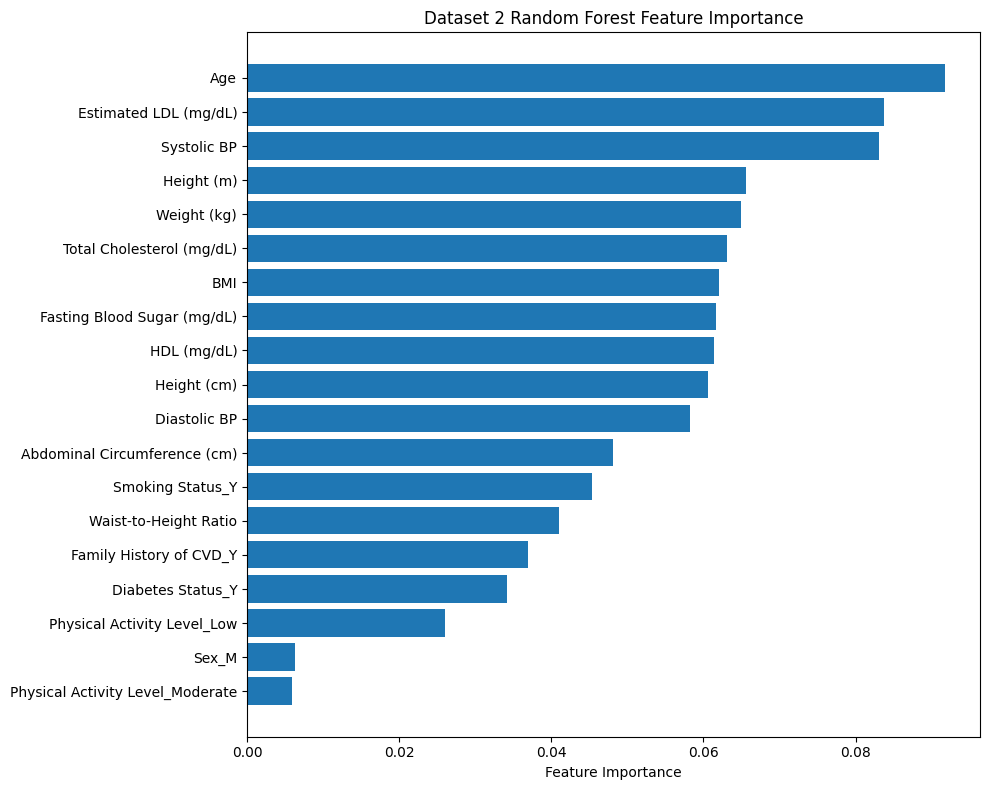

,Feature,Importance
0,Age,0.091765
12,Estimated LDL (mg/dL),0.083726
10,Systolic BP,0.083025
2,Height (m),0.065569
1,Weight (kg),0.064906
5,Total Cholesterol (mg/dL),0.063163
3,BMI,0.062026
7,Fasting Blood Sugar (mg/dL),0.061708
6,HDL (mg/dL),0.061385
8,Height (cm),0.060580


In [ ]:
rf2 = clone(models2["Random Forest"])
rf2.fit(X2_train, y2_train)

rf2_importance = pd.DataFrame({
    "Feature": X2.columns,
    "Importance": rf2.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(rf2_importance["Feature"], rf2_importance["Importance"])
plt.xlabel("Feature Importance")
plt.title("Dataset 2 Random Forest Feature Importance")
plt.tight_layout()
plt.show()

rf2_importance.sort_values(by="Importance", ascending=False).head(20)


## Cell 21: SHAP Analysis for Dataset 2

SHAP is used here to inspect which variables contribute most strongly to CVD risk predictions.


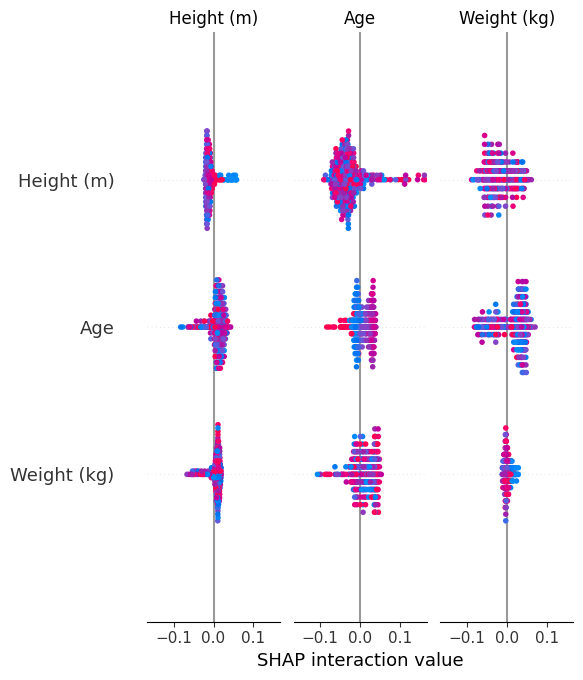

In [ ]:
try:
    import shap
except ImportError:
    !pip install shap
    import shap

best_model2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=321,
    class_weight="balanced"
)
best_model2.fit(X2_train, y2_train)

explainer2 = shap.TreeExplainer(best_model2)
shap_values2 = explainer2.shap_values(X2_test)

shap.summary_plot(shap_values2, X2_test, feature_names=X2.columns)


## Cell 22: Save Model Results and Feature Importance Tables

This cell saves the main result tables so they can be included in a report or project folder.


In [ ]:
OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/ENBC 321/ML Project/cvd_model_outputs'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

results1_df.to_csv(f'{OUTPUT_DIR}/dataset1_model_results.csv', index=False)
summary1_ci.to_csv(f'{OUTPUT_DIR}/dataset1_repeated_accuracy_ci.csv', index=False)
rf1_importance.sort_values(by="Importance", ascending=False).to_csv(f'{OUTPUT_DIR}/dataset1_random_forest_importance.csv', index=False)
perm1_df.sort_values(by="Importance", ascending=False).to_csv(f'{OUTPUT_DIR}/dataset1_permutation_importance.csv', index=False)
pca_results1_df.to_csv(f'{OUTPUT_DIR}/dataset1_pca_results.csv', index=False)

results2_df.to_csv(f'{OUTPUT_DIR}/dataset2_model_results.csv', index=False)
summary2_ci.to_csv(f'{OUTPUT_DIR}/dataset2_repeated_accuracy_ci.csv', index=False)
rf2_importance.sort_values(by="Importance", ascending=False).to_csv(f'{OUTPUT_DIR}/dataset2_random_forest_importance.csv', index=False)

print(f"Saved outputs to: {OUTPUT_DIR}")


## Cell 23: Brief Results Summary

This cell prints a short summary of the best-performing models from each dataset.


In [ ]:
best_dataset1 = results1_df.sort_values(by="Accuracy", ascending=False).iloc[0]
best_dataset2 = results2_df.sort_values(by="Accuracy", ascending=False).iloc[0]

print("Dataset 1 Best Model")
print(f"Model: {best_dataset1['Model']}")
print(f"Accuracy: {best_dataset1['Accuracy']:.3f}")
print(f"F1 Score: {best_dataset1['F1 Score']:.3f}")
print(f"ROC-AUC: {best_dataset1['ROC-AUC']:.3f}")

print("\nDataset 2 Best Model")
print(f"Model: {best_dataset2['Model']}")
print(f"Accuracy: {best_dataset2['Accuracy']:.3f}")
print(f"F1 Score: {best_dataset2['F1 Score']:.3f}")
print(f"ROC-AUC: {best_dataset2['ROC-AUC']:.3f}")


Dataset 1 Best Model
Model: Random Forest
Accuracy: 0.946
F1 Score: 0.948
ROC-AUC: 0.989

Dataset 2 Best Model
Model: Logistic Regression
Accuracy: 0.657
F1 Score: 0.612
ROC-AUC: 0.772
